# Baselines
Multimodal Workflow Cost Estimator.

In [1]:
import pandas as pd
import os
import math

In [2]:
from data_loading import load_latency_data

In [3]:
from constants import DEFAULT_WORKFLOW_CONFIG

In [4]:
data_dir = "data/"
results_dir = "results/"

In [5]:
os.makedirs(results_dir, exist_ok=True)

## Workflow Config and Model Profiles

In [6]:
# StreamCast: Podcast generation
# for a 10 minute / 600 seconds video
workflow_config = DEFAULT_WORKFLOW_CONFIG

In [7]:
latency_data = load_latency_data(data_dir=data_dir)

## Multi-Requests

In [8]:
import pandas as pd

from sim_types import GPUType
from sim_types import Model

from multirequests import get_time_per_request_baseline
from multirequests import get_replicas
from multirequests import get_costs
from multirequests import QPM_LIST
from multirequests import INIT_REPLICAS_BASELINE

from data_loading import load_latency_data

from workflows import PODCAST_WORKFLOW

from constants import GPU_RESERVED_COST

In [9]:
data_dir = "data/"

In [10]:
latency_data = load_latency_data(data_dir=data_dir)

time_per_req_baseline = get_time_per_request_baseline(
    workflow_config=PODCAST_WORKFLOW,
    latency_data=latency_data,
    init_replicas=INIT_REPLICAS_BASELINE,
)

total_time_per_req = 0
for gpu_type in time_per_req_baseline:
    for model in time_per_req_baseline[gpu_type]:
        total_time_per_req += time_per_req_baseline[gpu_type][model]

In [11]:
print("Initial replicas (8 A100 baseline setup):")
for gpu_type, gpu_replicas in INIT_REPLICAS_BASELINE.items():
    print(f"  {gpu_type.value}:")
    for component, model_replicas in gpu_replicas.items():
        print(f"    {component.value}: {model_replicas}")

Initial replicas (8 A100 baseline setup):
  A100:
    others: 1
    gemma: 1
    flux: 1
    hf: 1
    ft: 4
  H100:


In [12]:
replicas_baseline = get_replicas(
    video_seconds= 10 * 60,
    time_per_req=time_per_req_baseline,
    init_replicas=INIT_REPLICAS_BASELINE,
)

costs_baseline = get_costs(
    replicas=replicas_baseline,
    gpu_costs=GPU_RESERVED_COST,
)

In [13]:
print("Per-hour Cost for each component based on required replicas (Naive Baseline A100 - FCFS)")
df_costs_baseline = pd.DataFrame(costs_baseline[GPUType.A100])
df_costs_baseline["Total"] = df_costs_baseline.sum(axis=1)
df_costs_baseline.index.name = "QPM"
df_costs_baseline.rename(columns={
    Model.OTHERS: "Kokoro ($)",
    Model.GEMMA: "Gemma ($)",
    Model.FLUX: "Flux ($)",
    Model.HF: "HF+VAE ($)",
    Model.FT: "FantasyTalking ($)",
    "Total": "Total ($)",
})

Per-hour Cost for each component based on required replicas (Naive Baseline A100 - FCFS)


,Kokoro ($),Gemma ($),Flux ($),HF+VAE ($),FantasyTalking ($),Total ($)
QPM,,,,,,
0,3.4,3.4,3.4,44.2,561.0,615.4
1,3.4,3.4,3.4,414.8,5582.8,6007.8
2,3.4,6.8,3.4,829.6,11162.2,12005.4
3,10.2,10.2,3.4,2074.0,27903.8,30001.6
4,17.0,20.4,6.8,4148.0,55804.2,59996.4
5,30.6,40.8,13.6,8292.6,111605.0,119982.6
6,44.2,57.8,17.0,12440.6,167405.8,179965.4
7,74.8,95.2,30.6,20729.8,279007.4,299937.8
8,146.2,190.4,57.8,41459.6,558014.8,599868.8


In [14]:
# Output results to DataFrame and CSV
df_costs_baseline.rename(columns={
    Model.OTHERS: "Kokoro ($)",
    Model.GEMMA: "Gemma ($)",
    Model.FLUX: "Flux ($)",
    Model.HF: "HF+VAE ($)",
    Model.FT: "FantasyTalking ($)",
    "Total": "Total ($)",
})

# Save to CSV (optional, uncomment if needed)
# df_multi_req_cost_baseline.to_csv("results/baseline/multi_req_cost_naive_baseline_fcfs.csv", index=False)

,Kokoro ($),Gemma ($),Flux ($),HF+VAE ($),FantasyTalking ($),Total ($)
QPM,,,,,,
0,3.4,3.4,3.4,44.2,561.0,615.4
1,3.4,3.4,3.4,414.8,5582.8,6007.8
2,3.4,6.8,3.4,829.6,11162.2,12005.4
3,10.2,10.2,3.4,2074.0,27903.8,30001.6
4,17.0,20.4,6.8,4148.0,55804.2,59996.4
5,30.6,40.8,13.6,8292.6,111605.0,119982.6
6,44.2,57.8,17.0,12440.6,167405.8,179965.4
7,74.8,95.2,30.6,20729.8,279007.4,299937.8
8,146.2,190.4,57.8,41459.6,558014.8,599868.8


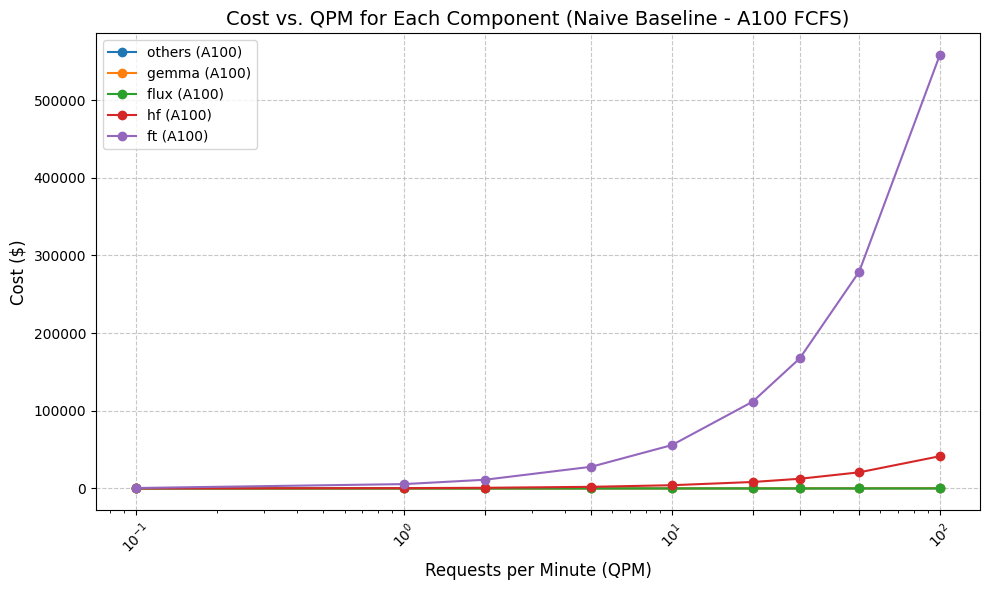

In [15]:
import matplotlib.pyplot as plt

# Plot cost vs QPM for each component (Naive Baseline - FCFS)
plt.figure(figsize=(10, 6))
for gpu_type in costs_baseline.keys():
    for model in costs_baseline[gpu_type].keys():
        plt.plot(QPM_LIST, costs_baseline[gpu_type][model], marker='o', label=f'{model.value} ({gpu_type.value})')

plt.xscale('log')

plt.xlabel('Requests per Minute (QPM)', fontsize=12)
plt.ylabel('Cost ($)', fontsize=12)
plt.title('Cost vs. QPM for Each Component (Naive Baseline - A100 FCFS)', fontsize=14)

plt.xticks(QPM_LIST, rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## SLO Categories

In [16]:
# Model three request categories with different SLO requirements
# Each category has 1/3 of total requests
# 1. Tight SLO: Must meet baseline time (100% of total_time_per_req)
# 2. Relaxed SLO: Can take 50% longer (150% of total_time_per_req)
# 3. Batch (no SLO): No time constraints

# SLO relaxation factor
slo_relaxation_factor = 0.5  # 50% relaxation

# Define SLO categories
slo_categories = {
    "tight": {
        "fraction": 1/3,
        "slo_multiplier": 1.0,  # Must complete in baseline time
        "description": "Tight SLO (100% of baseline)"
    },
    "relaxed": {
        "fraction": 1/3,
        "slo_multiplier": 1.0 + slo_relaxation_factor,  # Can take 50% longer
        "description": f"Relaxed SLO ({int((1 + slo_relaxation_factor)*100)}% of baseline)"
    },
    "batch": {
        "fraction": 1/3,
        "slo_multiplier": float('inf'),  # No SLO constraint
        "description": "Batch (no SLO)"
    }
}

print("=== SLO Category Configuration ===")
for category, config in slo_categories.items():
    print(f"{category.capitalize()}: {config['description']}")
    print(f"  Fraction of requests: {config['fraction']:.2%}")
    if config['slo_multiplier'] != float('inf'):
        print(f"  Allowed time: {config['slo_multiplier']:.1f}x baseline time = {config['slo_multiplier'] * total_time_per_req:.2f}s")
    else:
        print(f"  Allowed time: No constraint")
    print()

=== SLO Category Configuration ===
Tight: Tight SLO (100% of baseline)
  Fraction of requests: 33.33%
  Allowed time: 1.0x baseline time = 32003.29s

Relaxed: Relaxed SLO (150% of baseline)
  Fraction of requests: 33.33%
  Allowed time: 1.5x baseline time = 48004.93s

Batch: Batch (no SLO)
  Fraction of requests: 33.33%
  Allowed time: No constraint



In [17]:
# NAIVE FCFS: All requests treated equally regardless of SLO
# Since FCFS is SLO-unaware, replicas needed are same as before
# (already calculated in previous cells as replicas_*_baseline)

# However, we need to check if tight SLO requests can meet their deadlines
# In FCFS, average waiting time increases linearly with load
# For tight SLO requests to meet deadlines, we need enough capacity

replicas_naive_slo: dict[GPUType, dict[Model, list[float]]] = {}

for qpm in QPM_LIST:
    arrival_rate = qpm / 60
    
    # In FCFS with mixed SLOs, we must provision for tight SLO (worst case)
    # Tight SLO requests (1/3 of traffic) must complete within total_time_per_req
    # Relaxed and batch requests can wait longer, but tight cannot
    # So we provision based on tight SLO requirements
    
    tight_arrival_rate = arrival_rate * slo_categories["tight"]["fraction"]
    
    # For tight SLO in FCFS: need replicas = arrival_rate * service_time / target_utilization
    # Using 0.9 utilization to keep queue manageable
    target_utilization = 0.9
    
    for gpu_type in time_per_req_baseline.keys():
        if gpu_type not in replicas_naive_slo:
            replicas_naive_slo[gpu_type] = {}
        for model in time_per_req_baseline[gpu_type].keys():
            # TODO model HF+VAE combined
            if model not in replicas_naive_slo[gpu_type]:
                replicas_naive_slo[gpu_type][model] = []
            replica_naive_slo = max(1, math.ceil(arrival_rate * time_per_req_baseline[gpu_type][model] / target_utilization))
            replicas_naive_slo[gpu_type][model].append(replica_naive_slo)

In [18]:
print("Naive FCFS Replicas (SLO-unaware, provisioned for tight SLO) ===")
df_replicas_naive_slo = pd.DataFrame(
    replicas_naive_slo[GPUType.A100],
)
df_replicas_naive_slo.index.name = "QPM"
df_replicas_naive_slo["Total"] = df_replicas_naive_slo.sum(axis=1)
df_replicas_naive_slo.rename(columns={
    Model.OTHERS: "Kokoro",
    Model.GEMMA: "Gemma",
    Model.FLUX: "Flux",
    Model.HF: "HF+VAE",
    Model.FT: "FantasyTalking",
})

Naive FCFS Replicas (SLO-unaware, provisioned for tight SLO) ===


,Kokoro,Gemma,Flux,HF+VAE,FantasyTalking,Total
QPM,,,,,,
0,1,1,1,14,46,63
1,1,1,1,136,456,595
2,1,2,1,271,912,1187
3,3,4,1,678,2280,2966
4,5,7,2,1355,4559,5928
5,10,13,4,2710,9118,11855
6,15,19,6,4065,13677,17782
7,24,31,10,6775,22795,29635
8,48,62,19,13549,45590,59268


In [19]:
# DEADLINE-AWARE: Prioritizes tight SLO requests
# Key insight: Relaxed and batch requests can tolerate longer wait times
# So we can provision less aggressively by serving tight SLO first

replicas_deadline_aware: dict[GPUType, dict[Model, list[float]]] = {}

for qpm in QPM_LIST:
    arrival_rate = qpm / 60
    
    # Split traffic by category
    tight_arrival = arrival_rate * slo_categories["tight"]["fraction"]
    relaxed_arrival = arrival_rate * slo_categories["relaxed"]["fraction"]
    batch_arrival = arrival_rate * slo_categories["batch"]["fraction"]
    
    # Deadline-aware scheduling: tight SLO gets priority
    # Tight SLO: needs full capacity (must complete quickly)
    # Relaxed SLO: can use 1.5x longer, so effectively 1/1.5 = 0.67x capacity needed
    # Batch: no SLO, can use spare capacity
    
    # Effective arrival rate accounting for different SLOs
    # Tight requests need immediate service, relaxed can wait longer
    relaxed_multiplier = 1.0 / slo_categories["relaxed"]["slo_multiplier"]
    
    effective_arrival = \
        tight_arrival + \
        (relaxed_arrival * relaxed_multiplier) + \
        (batch_arrival * 0.3)  # Batch uses leftover capacity
    
    # Provision based on effective arrival rate with higher utilization (0.95) 
    # since deadline-aware scheduling is more efficient
    target_utilization = 0.95

    # replicas_deadline_aware = {}
    for gpu_type in time_per_req_baseline.keys():
        if gpu_type not in replicas_deadline_aware:
            replicas_deadline_aware[gpu_type] = {}
        for model in time_per_req_baseline[gpu_type].keys():
            if model not in replicas_deadline_aware[gpu_type]:
                replicas_deadline_aware[gpu_type][model] = []
            num_replicas = max(1, math.ceil(effective_arrival * time_per_req_baseline[gpu_type][model] / target_utilization))
            replicas_deadline_aware[gpu_type][model].append(num_replicas)

In [20]:
print("Deadline-Aware Replicas (Prioritizes tight SLO)")
df_replicas_deadline_aware = pd.DataFrame(
    replicas_deadline_aware[GPUType.A100],
)
df_replicas_deadline_aware.index.name = "QPM"
df_replicas_deadline_aware["Total"] = df_replicas_deadline_aware.sum(axis=1)
df_replicas_deadline_aware.rename(columns={
    Model.OTHERS: "Kokoro",
    Model.GEMMA: "Gemma",
    Model.FLUX: "Flux",
    Model.HF: "HF+VAE",
    Model.FT: "FantasyTalking",
})

Deadline-Aware Replicas (Prioritizes tight SLO)


,Kokoro,Gemma,Flux,HF+VAE,FantasyTalking,Total
QPM,,,,,,
0,1,1,1,9,29,41
1,1,1,1,85,284,372
2,1,1,1,169,567,739
3,2,2,1,421,1416,1842
4,3,4,2,842,2832,3683
5,6,8,3,1683,5663,7363
6,9,12,4,2525,8494,11044
7,15,20,6,4208,14157,18406
8,30,39,12,8415,28314,36810


In [21]:
# Calculate costs
df_costs_baseline

costs_naive_slo = get_costs(
    replicas=replicas_naive_slo,
    gpu_costs=GPU_RESERVED_COST,
)
df_costs_naive_slo = pd.DataFrame(costs_naive_slo[GPUType.A100])

costs_deadline_aware = get_costs(
    replicas=replicas_deadline_aware,
    gpu_costs=GPU_RESERVED_COST,
)
df_costs_deadline_aware = pd.DataFrame(costs_deadline_aware[GPUType.A100])

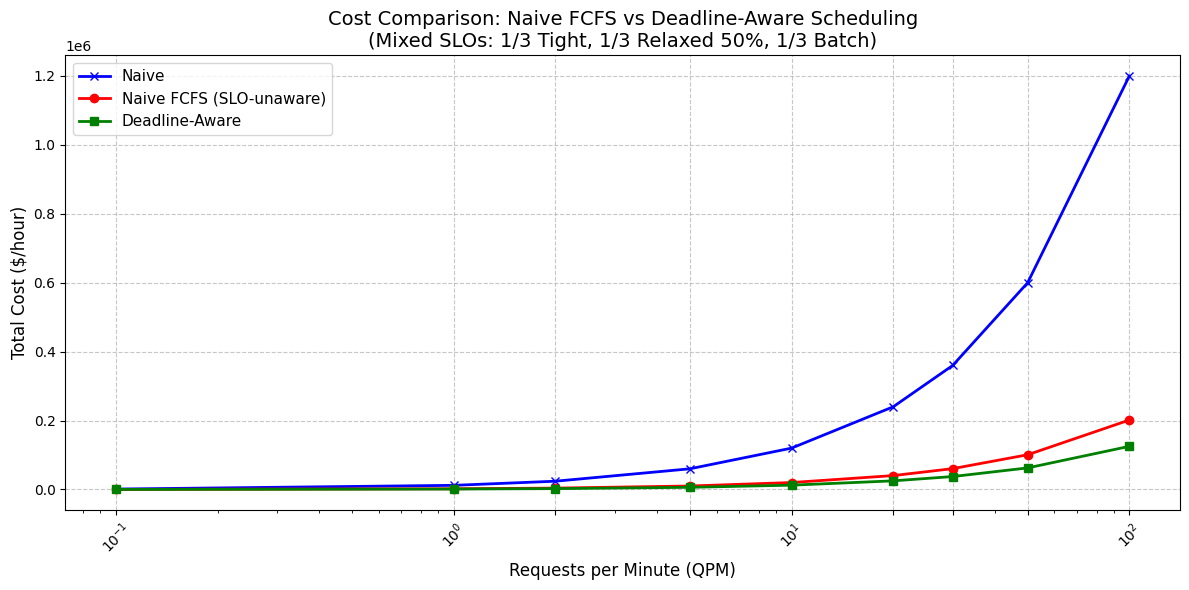

In [22]:
# Plot: Total Cost Comparison (Naive vs Deadline-Aware)
plt.figure(figsize=(12, 6))

plt.plot(
    QPM_LIST,
    df_costs_baseline.sum(axis=1).values,
    marker='x',
    linewidth=2,
    label='Naive',
    color='blue')
plt.plot(
    QPM_LIST,
    df_costs_naive_slo.sum(axis=1).values,
    marker='o',
    linewidth=2,
    label='Naive FCFS (SLO-unaware)',
    color='red')
plt.plot(
    QPM_LIST,
    df_costs_deadline_aware.sum(axis=1).values,
    marker='s',
    linewidth=2,
    label='Deadline-Aware',
    color='green')

plt.xscale('log')

plt.xlabel('Requests per Minute (QPM)', fontsize=12)
plt.ylabel('Total Cost ($/hour)', fontsize=12)
plt.title('Cost Comparison: Naive FCFS vs Deadline-Aware Scheduling\n(Mixed SLOs: 1/3 Tight, 1/3 Relaxed 50%, 1/3 Batch)', fontsize=14)

plt.xticks(QPM_LIST, rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [23]:
# Compute costs from previous cells instead of using hardcoded values
naive_costs = df_costs_baseline.sum(axis=1).tolist()
sw_costs = df_costs_naive_slo.sum(axis=1).tolist()

df_costs_summary = pd.DataFrame({
    "QPM": QPM_LIST,
    "Naive ($)": df_costs_baseline.sum(axis=1),
    "SW Uniform ($)": df_costs_naive_slo.sum(axis=1),
    "SW Deadline ($)": df_costs_deadline_aware.sum(axis=1),
}).set_index("QPM")
df_costs_summary["Total reduction"] = (
    df_costs_summary["Naive ($)"] - df_costs_summary["SW Deadline ($)"]
) / df_costs_summary["Naive ($)"] * 100

df_costs_summary


,Naive ($),SW Uniform ($),SW Deadline ($),Total reduction
QPM,,,,
0.1,1230.8,214.2,139.4,88.674033
1.0,12015.6,2023.0,1264.8,89.473684
2.0,24010.8,4035.8,2512.6,89.535542
5.0,60003.2,10084.4,6262.8,89.562557
10.0,119992.8,20155.2,12522.2,89.564207
20.0,239965.2,40307.0,25034.2,89.567571
30.0,359930.8,60458.8,37549.6,89.567550
50.0,599875.6,100759.0,62580.4,89.567770
100.0,1199737.6,201511.2,125154.0,89.568219
